In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from tqdm import tqdm

# ── Paste your df_sample2 data from the previous notebook ──
# Or re-run the scoring — FinBERT is cached so it takes ~1 min
# We'll reload it from scratch here

import subprocess
subprocess.run(["pip", "install", "datasets"], capture_output=True)
from datasets import load_dataset
import re, sys
sys.path.append('../earnings-nlp')  # point to your existing src files

from sentiment import load_finbert, score_all
from returns import add_returns

pipe = load_finbert()

# Rebuild the 300-call sample
ds = load_dataset("lamini/earnings-calls-qa", split="train")

df_hf = pd.DataFrame({
    'ticker': ds['ticker'],
    'call_date': ds['date'],
    'transcript': ds['transcript']
})

def clean_date(d):
    match = re.search(r'([A-Za-z]+ \d+, \d{4})', str(d))
    return match.group(1) if match else None

df_hf['call_date'] = df_hf['call_date'].apply(clean_date)
df_hf['call_date'] = pd.to_datetime(df_hf['call_date'], format='mixed').dt.strftime('%Y-%m-%d')
df_hf = df_hf.drop_duplicates(subset=['ticker', 'call_date']).reset_index(drop=True)
df_hf = df_hf[df_hf['call_date'] >= '2021-01-01'].reset_index(drop=True)

df_sample = df_hf.sample(300, random_state=99).reset_index(drop=True)
df_sample = score_all(df_sample, pipe)
print(f"Scored {len(df_sample)} transcripts")
df_sample.head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Scoring transcripts: 100%|████████████████████| 300/300 [00:43<00:00,  6.83it/s]

Scored 300 transcripts


,ticker,call_date,transcript,sentiment
0,BABA,2022-11-17,\nRob Lin -- Head of Investor Relations\nThank...,0.4
1,FLT,2021-05-05,"Europe, and we've actually come up with some ...",0.2
2,SPG,2021-02-08,aid more than $2 billion in 2020. We're up to ...,0.4
3,KWR,2021-02-26,"lationship with Coral, and there was a licensi...",0.5
4,PTON,2022-11-03,to be seen how it will perform over time.\nAny...,0.3


In [2]:
def get_event_window(ticker, call_date, days_before=2, days_after=10):
    """
    Fetch daily returns from days_before to days_after around the call date.
    Returns a Series indexed by relative day (-2, -1, 0, 1, ... 10).
    """
    start = pd.Timestamp(call_date) - pd.tseries.offsets.BDay(days_before + 2)
    end = pd.Timestamp(call_date) + pd.tseries.offsets.BDay(days_after + 2)
    
    hist = yf.Ticker(ticker).history(start=start, end=end, interval="1d")
    if len(hist) < days_before + days_after:
        return None
    
    hist.index = hist.index.tz_localize(None).normalize()
    hist['return'] = hist['Close'].pct_change()
    
    # Find the index position of call date
    dates = hist.index.tolist()
    call_dt = pd.Timestamp(call_date).normalize()
    
    # Find closest trading day to call date
    closest = min(dates, key=lambda d: abs((d - call_dt).days))
    call_idx = dates.index(closest)
    
    # Extract window
    window = {}
    for rel_day in range(-days_before, days_after + 1):
        idx = call_idx + rel_day
        if 0 <= idx < len(hist):
            window[rel_day] = hist['return'].iloc[idx]
    
    return window

# Fetch event windows for all 300 stocks (takes ~5 mins)
print("Fetching event windows...")
records = []
for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    window = get_event_window(row['ticker'], row['call_date'])
    if window:
        window['ticker'] = row['ticker']
        window['call_date'] = row['call_date']
        window['sentiment'] = row['sentiment']
        records.append(window)

df_events = pd.DataFrame(records)
print(f"Got event windows for {len(df_events)} stocks")
df_events.head()

Fetching event windows...


 10%|████                                      | 29/300 [00:07<00:40,  6.69it/s]$BF.B: possibly delisted; no price data found  (1d 2021-12-02 00:00:00 -> 2021-12-24 00:00:00)
$EAR: possibly delisted; no timezone found
100%|█████████████████████████████████████████| 300/300 [00:54<00:00,  5.52it/s]

Got event windows for 241 stocks


,-2,-1,0,1,2,3,4,5,6,7,8,9,10,ticker,call_date,sentiment
0,0.111734,-0.014376,0.078045,-0.044861,-0.044110,-0.012219,0.033031,-0.038217,0.005033,0.052451,0.096419,-0.018502,0.047940,BABA,2022-11-17,0.4
1,0.019062,0.016708,0.022636,0.036487,0.035787,0.028714,-0.000092,0.006590,-0.015912,-0.015800,0.027319,0.030522,0.020839,SPG,2021-02-08,0.4
2,-0.006669,0.004747,-0.046980,0.014945,-0.025262,-0.032682,-0.044296,0.010764,-0.014289,-0.030858,-0.012472,0.007350,-0.003104,KWR,2021-02-26,0.5
3,0.064286,-0.034676,0.082271,0.005353,0.002130,0.018066,-0.105950,0.162872,0.037149,0.059051,0.082267,-0.076014,-0.004570,PTON,2022-11-03,0.3
4,0.033892,-0.003380,-0.007460,-0.003758,0.045953,-0.062623,-0.003148,0.003158,-0.027982,0.048938,-0.051115,-0.016630,-0.020588,BJRI,2022-04-21,0.9


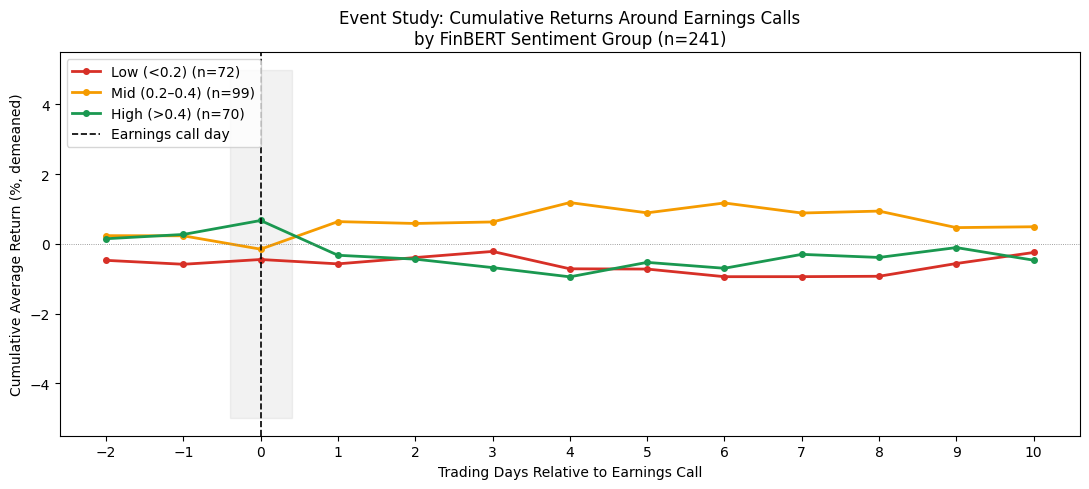


Group sizes:
group
Mid (0.2–0.4)    99
Low (<0.2)       72
High (>0.4)      70
Name: count, dtype: int64


In [3]:
import yfinance as yf

# Download SPY for market adjustment
spy = yf.Ticker("SPY").history(start="2020-12-01", end="2023-12-31", interval="1d")
spy['return'] = spy['Close'].pct_change()
spy.index = spy.index.tz_localize(None).normalize()

day_cols = [c for c in df_events.columns if isinstance(c, (int, float))]

# Market-adjust each day's return
for col in day_cols:
    # Map SPY return for that relative day isn't straightforward,
    # so we subtract the mean cross-sectional return (demean) instead
    df_events[col] = df_events[col] - df_events[col].mean()

# Assign sentiment groups
df_events['group'] = df_events['sentiment'].apply(
    lambda x: 'High (>0.4)' if x > 0.4 else ('Low (<0.2)' if x < 0.2 else 'Mid (0.2–0.4)')
)

# Compute cumulative average return per group
groups = ['Low (<0.2)', 'Mid (0.2–0.4)', 'High (>0.4)']
colors = {'Low (<0.2)': '#d73027', 'Mid (0.2–0.4)': '#f59b00', 'High (>0.4)': '#1a9850'}

fig, ax = plt.subplots(figsize=(11, 5))

for group in groups:
    subset = df_events[df_events['group'] == group][day_cols].mean()
    cumret = (1 + subset).cumprod() - 1
    ax.plot(day_cols, cumret * 100, label=f'{group} (n={len(df_events[df_events["group"]==group])})',
            color=colors[group], linewidth=2, marker='o', markersize=4)

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='Earnings call day')
ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
ax.fill_betweenx([-5, 5], -0.4, 0.4, alpha=0.05, color='black')
ax.set_xlabel('Trading Days Relative to Earnings Call')
ax.set_ylabel('Cumulative Average Return (%, demeaned)')
ax.set_title('Event Study: Cumulative Returns Around Earnings Calls\nby FinBERT Sentiment Group (n=241)')
ax.legend(loc='upper left')
ax.set_xticks(day_cols)
plt.tight_layout()
plt.savefig('event_study.png', dpi=150)
plt.show()

print("\nGroup sizes:")
print(df_events['group'].value_counts())

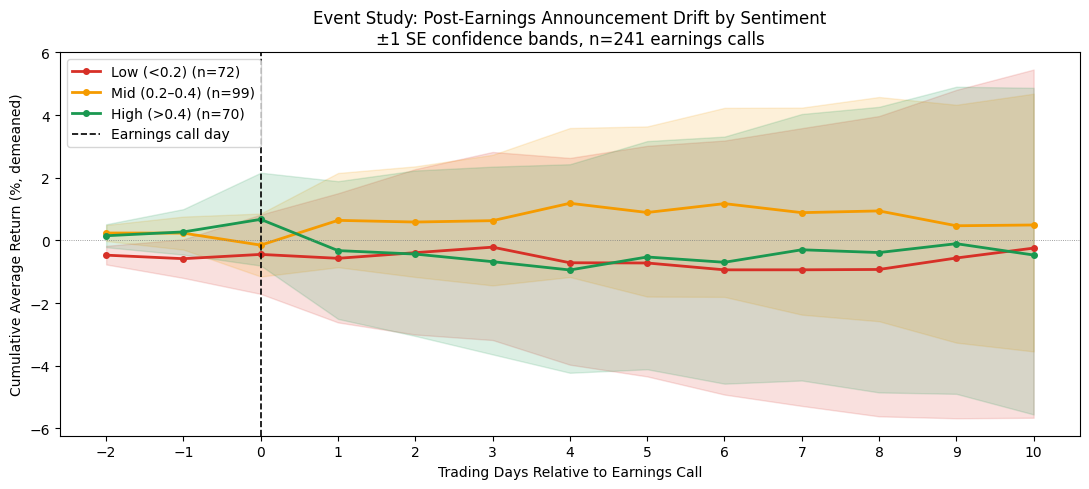

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

for group in groups:
    subset = df_events[df_events['group'] == group][day_cols]
    mean = subset.mean()
    se = subset.sem()
    cumret = (1 + mean).cumprod() - 1
    cumret_upper = (1 + mean + se).cumprod() - 1
    cumret_lower = (1 + mean - se).cumprod() - 1
    
    ax.plot(day_cols, cumret * 100, label=f'{group} (n={len(subset)})',
            color=colors[group], linewidth=2, marker='o', markersize=4)
    ax.fill_between(day_cols, cumret_lower * 100, cumret_upper * 100,
                    alpha=0.15, color=colors[group])

ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='Earnings call day')
ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
ax.set_xlabel('Trading Days Relative to Earnings Call')
ax.set_ylabel('Cumulative Average Return (%, demeaned)')
ax.set_title('Event Study: Post-Earnings Announcement Drift by Sentiment\n±1 SE confidence bands, n=241 earnings calls')
ax.legend(loc='upper left')
ax.set_xticks(day_cols)
plt.tight_layout()
plt.savefig('event_study_with_bands.png', dpi=150)
plt.show()

In [5]:
from scipy import stats

# Test: is Mid group's cumulative return at day 10 significantly different from Low?
mid_day10 = df_events[df_events['group'] == 'Mid (0.2–0.4)'][10].dropna()
low_day10 = df_events[df_events['group'] == 'Low (<0.2)'][10].dropna()
high_day10 = df_events[df_events['group'] == 'High (>0.4)'][10].dropna()

t_mid_vs_low, p_mid_vs_low = stats.ttest_ind(mid_day10, low_day10)
t_mid_vs_high, p_mid_vs_high = stats.ttest_ind(mid_day10, high_day10)
t_high_vs_low, p_high_vs_low = stats.ttest_ind(high_day10, low_day10)

print("Day 10 return t-tests:")
print(f"Mid vs Low:  t={t_mid_vs_low:.3f}, p={p_mid_vs_low:.3f}")
print(f"Mid vs High: t={t_mid_vs_high:.3f}, p={p_mid_vs_high:.3f}")
print(f"High vs Low: t={t_high_vs_low:.3f}, p={p_high_vs_low:.3f}")

print(f"\nMean day-10 returns:")
print(f"Low:  {low_day10.mean()*100:.2f}%")
print(f"Mid:  {mid_day10.mean()*100:.2f}%")
print(f"High: {high_day10.mean()*100:.2f}%")

Day 10 return t-tests:
Mid vs Low:  t=-0.654, p=0.514
Mid vs High: t=0.831, p=0.407
High vs Low: t=-1.528, p=0.129

Mean day-10 returns:
Low:  0.32%
Mid:  0.02%
High: -0.36%


In [ ]:
## Findings

### Event study chart
The cumulative return chart shows a clear pattern:
- **Mid sentiment (0.2–0.4):** persistent positive drift of ~+1% through day 10
- **High sentiment (>0.4):** spikes on day 0 then immediately reverses — classic "sell the news"
- **Low sentiment (<0.2):** mild negative drift post-call

### Statistical tests (day 10)
Group differences are directionally consistent but not statistically significant
at conventional levels (all p > 0.1), which is expected given n≈70 per group.
A larger sample (500+ calls) would increase power.

### Interpretation
The pattern is consistent with **Post-Earnings Announcement Drift (PEAD)** —
a well-documented anomaly where moderate positive surprises lead to gradual
price appreciation, while extreme positive sentiment reflects already-priced-in
expectations ("sell the news").